In [1]:
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text

import numpy as np

from statsmodels.stats.multitest import multipletests

from figure_params import *


/home/njharlen/anaconda3/lib/python3.8/site-packages/pandas/core/computation/expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


## Figure 3A - FDC and FRC scores

In [2]:
m = pd.read_csv('../data/cell_type_fine_top20_markergenes_specific_method.csv')
adata_geo = sc.read('../data/FL_geomx.h5ad')

In [3]:
sc.pp.log1p(adata_geo)

In [4]:
sc.tl.score_genes(adata_geo,m.loc[m['cell_type_fine']=='FRC','names'],score_name='frc_sig')
sc.tl.score_genes(adata_geo,m.loc[m['cell_type_fine']=='FDC','names'],score_name='fdc_sig')

In [5]:
adata_geo.obs['disease_fine'] = adata_geo.obs['disease_fine'].replace({'DHL' : 'DLBCL'})
adata_geo.obs['disease_fine'] = adata_geo.obs['disease_fine'].replace({'FL3B' : 'FLBCL',
                                                                       'FL3B/DLBCL':'FLBCL',
                                                                      'DLBCL' : 'tFL-DLBCL'})

In [6]:
adata_geo.obs['disease_fine'] = pd.Categorical(adata_geo.obs['disease_fine'],categories=['FL','tFL-DLBCL','FLBCL'])

In [7]:
disease_colors.update({'tFL-DLBCL' : 'red','FLBCL' : 'purple'})

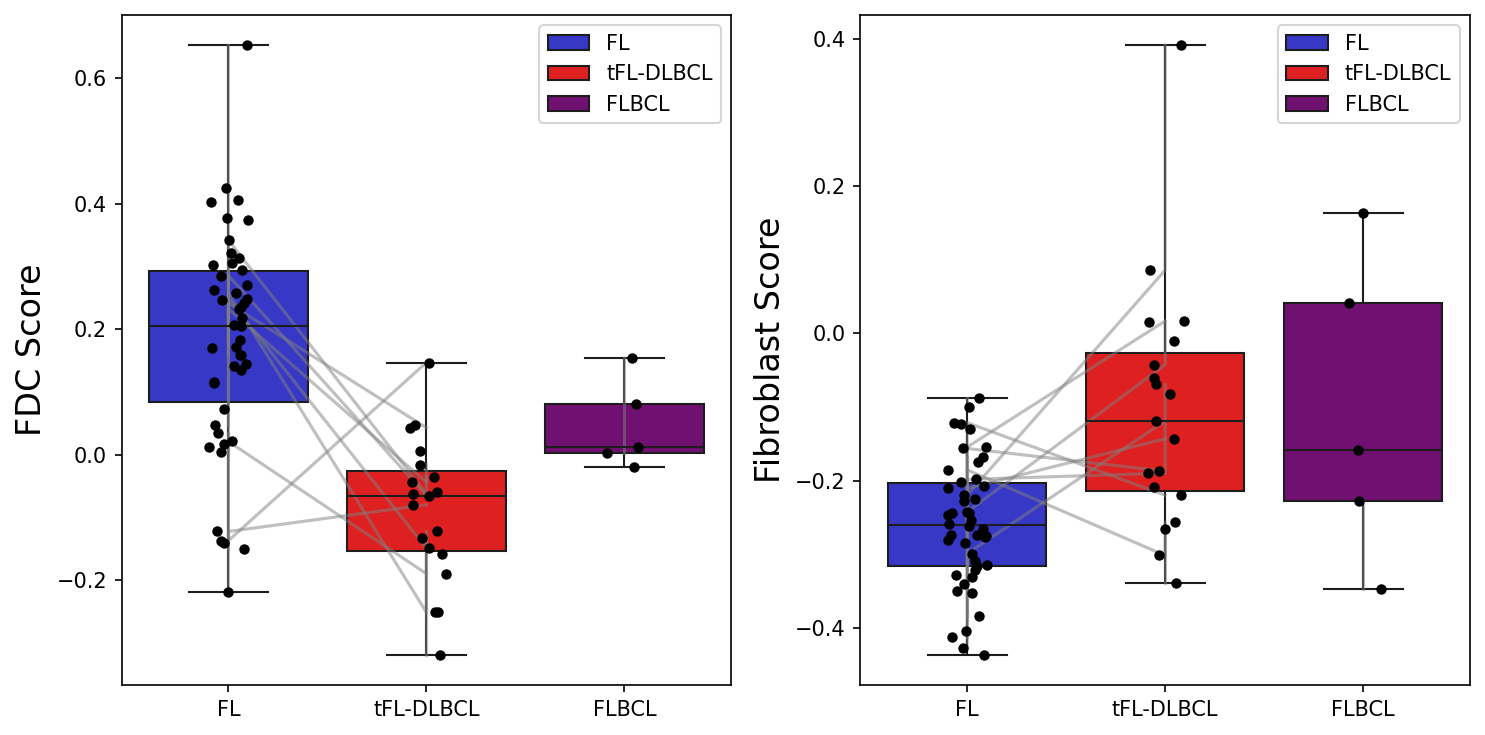

In [8]:
f,ax = plt.subplots(1,2,figsize=(10,5))
idx = adata_geo.obs['SegmentLabel']=='Bcell'

labels = ['FDC Score','Fibroblast Score']

i=0
for sig in ['fdc_sig','frc_sig']:
    sns.boxplot(x="disease_fine",y=sig,data=adata_geo.obs[idx],hue='disease_fine',
                palette=disease_colors,ax=ax[i],whis=100)
    sns.stripplot(x="disease_fine",y=sig,data=adata_geo.obs[idx],color='k',ax=ax[i])
    sns.lineplot(x="disease_fine",y=sig,units="patient",estimator=None,
             data=adata_geo.obs[idx],legend=False,color='grey',markers=False,ax=ax[i],alpha=.5)
    
    ax[i].set_ylabel(labels[i])
    ax[i].set_xlabel('')
    
    i+=1
    
plt.tight_layout()

## Figure 3B - Scatter plots FRC/FDC signatures against CXCL13/CCL19/21

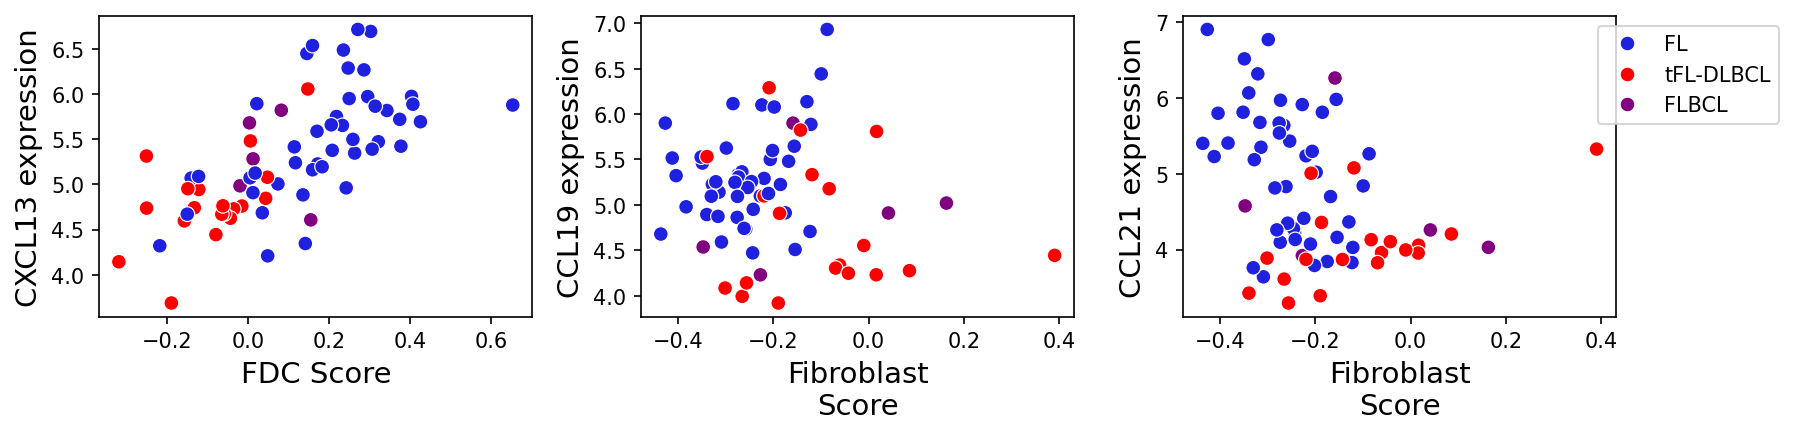

In [9]:
f,ax = plt.subplots(1,3,figsize=(12,3))

gs = ['CXCL13','CCL19','CCL21']
scores = ['fdc_sig','frc_sig','frc_sig']
sig_names = ['FDC Score','Fibroblast\nScore','Fibroblast\nScore']

i=0
for g,score in zip(gs,scores):
    idx = adata_geo.obs['SegmentLabel']=='Bcell'

    sns.scatterplot(x=score,y=adata_geo[idx,g].to_df()[g],
                    data=adata_geo[idx].obs,hue="disease_fine",s=50,ax=ax[i],palette=disease_colors)
    ax[i].set_xlabel(sig_names[i],fontsize=14)
    ax[i].set_ylabel(f'{g} expression',fontsize=14)
    
    if i<2:
        ax[i].legend().remove()
    else:
        ax[i].legend(bbox_to_anchor=(1.4,1))
    
    i+=1

plt.tight_layout()

## Figure 3C - Stromal U-MAP

In [10]:
adata_s = sc.read('../data/FL_stroma_v0.h5ad')

/home/njharlen/anaconda3/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


<Axes: title={'center': 'description'}, xlabel='UMAP1', ylabel='UMAP2'>

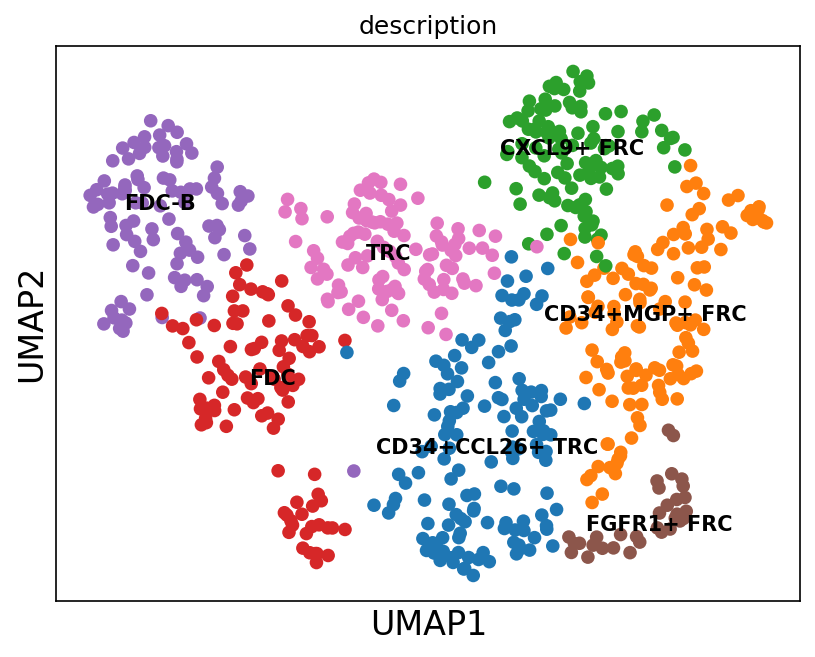

In [11]:
sc.pl.umap(adata_s,color='description',legend_loc = 'on data',show=False)


## Figure 3D - Stromal marker violins

/home/njharlen/anaconda3/lib/python3.8/site-packages/scanpy/plotting/_stacked_violin.py:461: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  row_ax = sns.violinplot(
/home/njharlen/anaconda3/lib/python3.8/site-packages/scanpy/plotting/_stacked_violin.py:461: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  row_ax = sns.violinplot(
/home/njharlen/anaconda3/lib/python3.8/site-packages/scanpy/plotting/_stacked_violin.py:461: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  row_ax = sns.violinplot(
/home/njharlen/anaconda3/lib/python3.8/site-packages/scanpy/plotting/_stacked_violin.py:461: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be remo

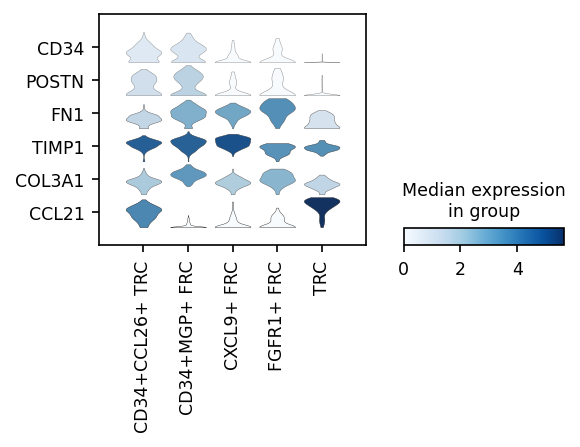

In [12]:
g = sc.pl.stacked_violin(adata_s[~adata_s.obs['description'].isin(['FDC','FDC-B'])],
              ['CD34','POSTN','FN1','TIMP1','COL3A1','CCL21'],
              groupby='description',swap_axes=True,figsize=(4,2),show=False)

## Figure 3E - CCL21+ vs - heatmap

{'heatmap_ax': <Axes: >,
 'groupby_ax': <Axes: ylabel='cell_type'>,
 'gene_groups_ax': <Axes: >}

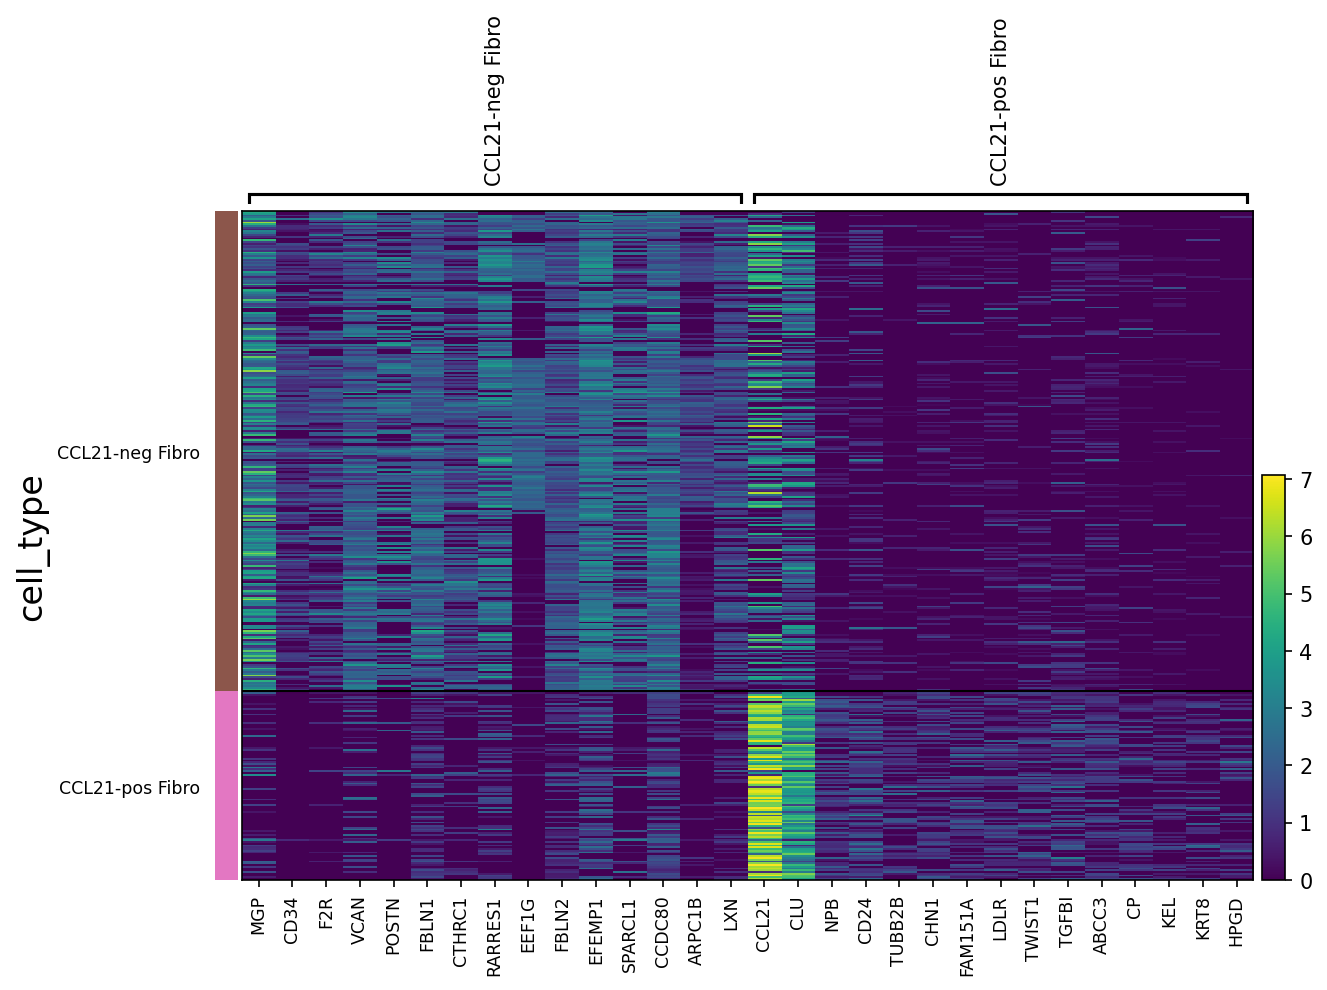

In [13]:
idx = adata_s.obs['description'].str.match('CD34|TRC')
adata_sub = adata_s[idx].copy()
adata_sub.obs['cell_type'] = adata_sub.obs['description'].astype(str)
adata_sub.obs.loc[adata_sub.obs['description']!="TRC",'cell_type'] = 'CCL21-neg Fibro'
adata_sub.obs.loc[adata_sub.obs['description']=="TRC",'cell_type'] = 'CCL21-pos Fibro'

sc.tl.rank_genes_groups(adata_sub,'cell_type')
sc.pl.rank_genes_groups_heatmap(adata_sub,n_genes=15,min_logfoldchange=2,show=False,dendrogram=False)

## Figure 3F - Cytokine volcano

In [14]:
df = pd.read_excel('../data/stables/Suppl. Table 4_GeoMx_limma.xlsx',
                  sheet_name='limma_tFL_vsFL_geomx_Brich',index_col=0)

In [15]:
cyto_list = pd.read_csv('../ref/GO_cytokine_activity_list_092024.txt',
                       sep='\t',header=None,names=['term','gene'])

In [16]:
# Restrict to cytokines and recompute FDR
df = df[df.index.isin(cyto_list['gene'])]
df['adj.P.Val'] = multipletests(df['P.Value'],method='fdr_bh')[1]

Text(0.5, 39.58333333333332, 'Log$_2$ fold-change')

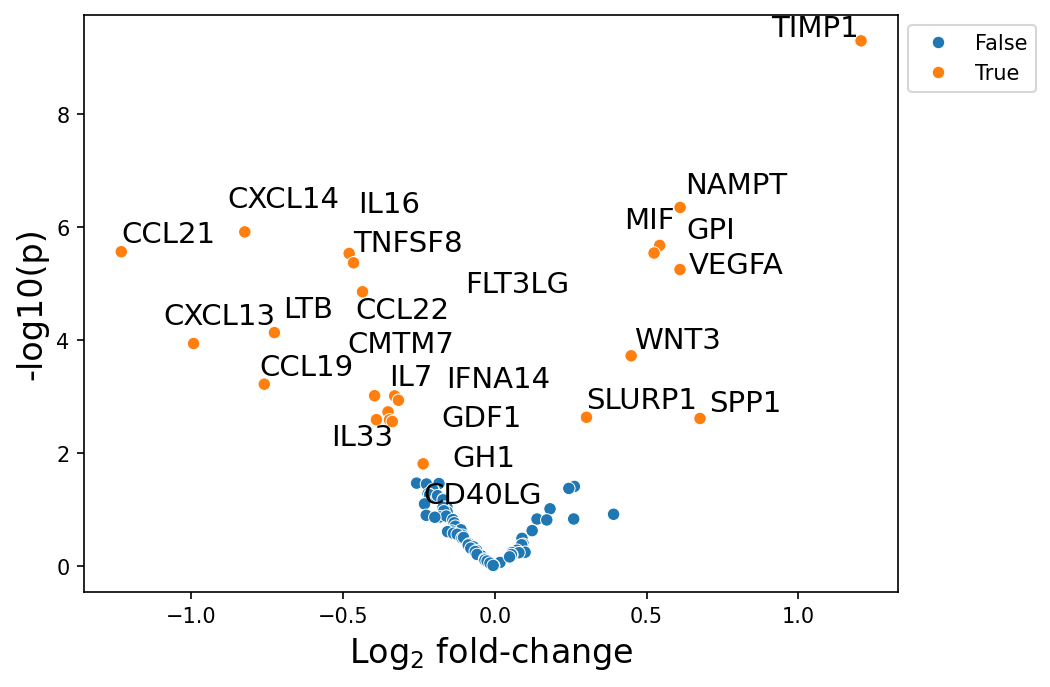

In [17]:
plt.figure(figsize=(7,5))
df['nlogp'] = -1*np.log10(df['P.Value'])
df['sig'] = df['adj.P.Val']<.1
sns.scatterplot(x="logFC",y="nlogp",data=df,hue='sig')

ts = list()
for ind,row in df[df['sig']].iterrows():
    t= plt.text(row['logFC'],row['nlogp'],ind,fontsize=14)
    ts.append(t)
    
adjust_text(ts)
plt.legend(bbox_to_anchor=(1,1))
plt.ylabel('-log10(p)')
plt.xlabel('Log$_2$ fold-change')

## Figure 3G - Bulk and GeoMX boxplots

### Bulk

In [18]:
X = pd.read_csv('../data/bulk_RNA_gene_expression_matrix.csv.gz',index_col='gene_name')
S = pd.read_csv('../data/bulk_metadata.txt',index_col='sample',sep='\t')

S = S[S['disease'].isin(['FL','tFL'])]
X = X.loc[:,S.index].T

/tmp/ipykernel_49972/761850156.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=S['disease'],y=g,data=X,ax=ax[i],whis=1000,palette=disease_colors)
/tmp/ipykernel_49972/761850156.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=S['disease'],y=g,data=X,ax=ax[i],whis=1000,palette=disease_colors)
/tmp/ipykernel_49972/761850156.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=S['disease'],y=g,data=X,ax=ax[i],whis=1000,palette=disease_colors)


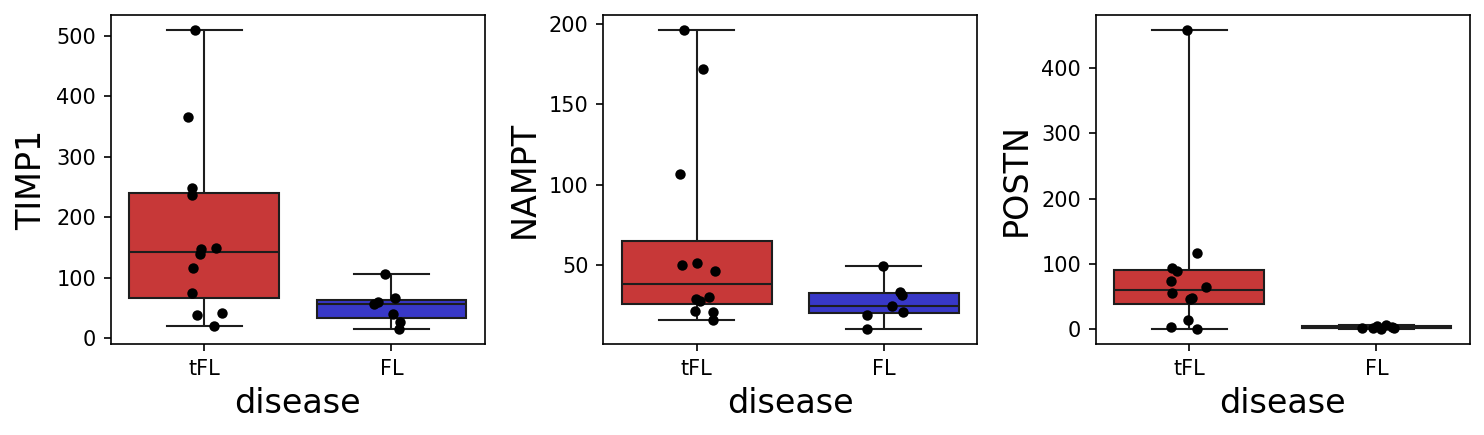

In [19]:
from scipy.stats import ranksums, ttest_ind
gshow = ['TIMP1','NAMPT','POSTN']

f,ax = plt.subplots(1,3,figsize=(10,3))
ax=ax.reshape(-1)

i=0
for g in gshow:
    sns.stripplot(x=S['disease'],y=g,data=X,ax=ax[i],color='k')
    sns.boxplot(x=S['disease'],y=g,data=X,ax=ax[i],whis=1000,palette=disease_colors)
    
    r,p = ranksums(X.loc[S['disease']=='FL',g],
            X.loc[S['disease']=='tFL',g])

    
    i+=1
plt.tight_layout()


### GeoMX

In [20]:
adata_geo = sc.read('../data/FL_geomx.h5ad')

/tmp/ipykernel_49972/2131252740.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='disease',y=g,data=df,ax=ax[i],whis=1000,palette=disease_colors)
/tmp/ipykernel_49972/2131252740.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='disease',y=g,data=df,ax=ax[i],whis=1000,palette=disease_colors)
/tmp/ipykernel_49972/2131252740.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='disease',y=g,data=df,ax=ax[i],whis=1000,palette=disease_colors)


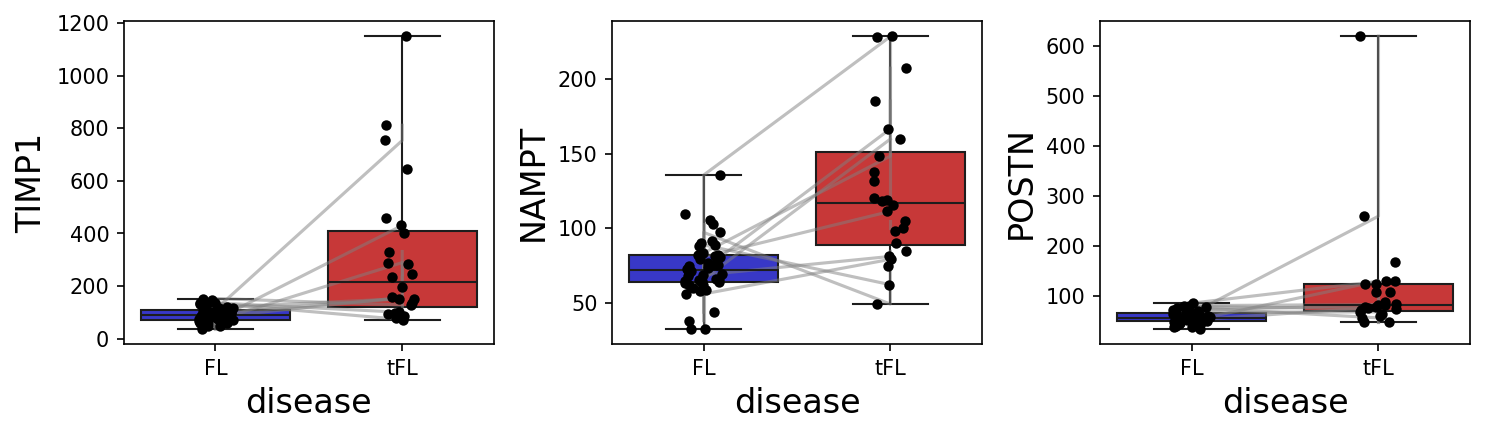

In [21]:
from scipy.stats import ranksums, ttest_ind
gshow = ['TIMP1','NAMPT','POSTN']

f,ax = plt.subplots(1,3,figsize=(10,3))
ax=ax.reshape(-1)

df = adata_geo[adata_geo.obs['SegmentLabel']=='Bcell',gshow].to_df().join(adata_geo.obs)

i=0
for g in gshow:
    sns.stripplot(x='disease',y=g,data=df,ax=ax[i],color='k')
    sns.boxplot(x='disease',y=g,data=df,ax=ax[i],whis=1000,palette=disease_colors)
    
    sns.lineplot(x="disease",y=g,units="patient",estimator=None,
             data=df,legend=False,color='grey',markers=False,ax=ax[i],alpha=.5)
    
    
    i+=1
plt.tight_layout()

## Figure 3H - CXCL13 interaction plots

In [22]:
from util import geomx_interaction_plot

In [23]:
sc.pp.log1p(adata_geo)

/home/njharlen/anaconda3/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


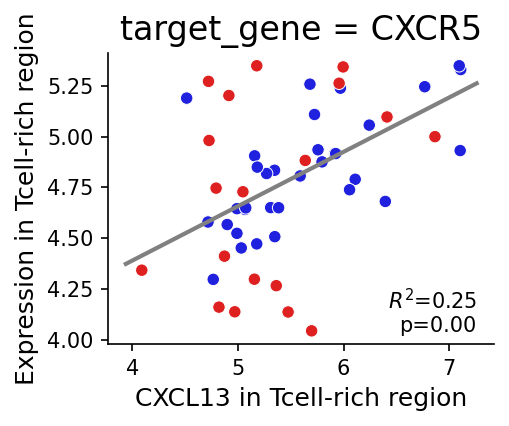

In [24]:
geomx_interaction_plot(adata_geo,
            source_gene='CXCL13',
            target_genes=['CXCR5'],
            source_region='Tcell',
            target_region='Tcell',hue="disease",plot_type='mixedlm',palette=disease_colors)

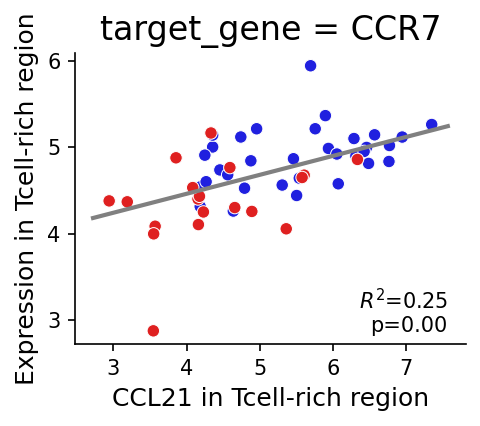

In [25]:
geomx_interaction_plot(adata_geo,
            source_gene='CCL21',
            target_genes=['CCR7'],
            source_region='Tcell',
            target_region='Tcell',hue="disease",plot_type='mixedlm',palette=disease_colors)